# Imports

In [257]:
import pandas as pd
import plotly.express as px
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Read in data
- use relative paths using Pathlib since it treats paths as objects

In [131]:
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / 'data' / 'raw' / 'PHY_R26_P05_V10_D24_Prov_Svc.csv'
df = pd.read_csv(data_path)

C:\Users\Advay\AppData\Local\Temp\ipykernel_33228\1111518388.py:3: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


# EDA
- first, exploring RAW DATA (df)
- then creating dfs for specific use-cases (df_paid as an example)

In [132]:
df.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


Notice that we see multiple providers with different HCPCS codes, which are codes that represent the service provided. That implies each row is a service done by a provider

In [133]:

df.dtypes

Rndrng_NPI                         int64
Rndrng_Prvdr_Last_Org_Name        object
Rndrng_Prvdr_First_Name           object
Rndrng_Prvdr_MI                   object
Rndrng_Prvdr_Crdntls              object
Rndrng_Prvdr_Ent_Cd               object
Rndrng_Prvdr_St1                  object
Rndrng_Prvdr_St2                  object
Rndrng_Prvdr_City                 object
Rndrng_Prvdr_State_Abrvtn         object
Rndrng_Prvdr_State_FIPS           object
Rndrng_Prvdr_Zip5                 object
Rndrng_Prvdr_RUCA                float64
Rndrng_Prvdr_RUCA_Desc            object
Rndrng_Prvdr_Cntry                object
Rndrng_Prvdr_Type                 object
Rndrng_Prvdr_Mdcr_Prtcptg_Ind     object
HCPCS_Cd                          object
HCPCS_Desc                        object
HCPCS_Drug_Ind                    object
Place_Of_Srvc                     object
Tot_Benes                          int64
Tot_Srvcs                        float64
Tot_Bene_Day_Srvcs                 int64
Avg_Sbmtd_Chrg  

Note that RUCA (rural urban code) is a float when it is a category so keep in mind when answering Q4 hypothesis

In [134]:
df.describe()

,Rndrng_NPI,Rndrng_Prvdr_RUCA,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
count,9.781673e+06,9.776382e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06
mean,1.499356e+09,1.548344e+00,8.498743e+01,2.818193e+02,1.372579e+02,4.307621e+02,1.063680e+02,8.300478e+01,8.249464e+01
std,2.877017e+08,3.347701e+00,1.312172e+03,6.307908e+03,2.181447e+03,1.521585e+03,3.329877e+02,2.656162e+02,2.671587e+02
min,1.003000e+09,1.000000e+00,1.100000e+01,4.400000e+00,1.100000e+01,3.508770e-05,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.245947e+09,1.000000e+00,1.700000e+01,2.100000e+01,2.000000e+01,7.328125e+01,2.548538e+01,1.965000e+01,1.947113e+01
50%,1.497941e+09,1.000000e+00,3.200000e+01,4.300000e+01,4.100000e+01,1.800000e+02,7.155108e+01,5.245652e+01,5.265500e+01
75%,1.740789e+09,1.000000e+00,7.200000e+01,1.190000e+02,1.060000e+02,3.670000e+02,1.211388e+02,9.091222e+01,9.077629e+01
max,1.993000e+09,9.900000e+01,8.967620e+05,6.486401e+06,1.835261e+06,9.999999e+04,5.396543e+04,4.299489e+04,4.299489e+04


Analysis
- Rndrng_NPI and Rndrng_Prvdr_RUCA don't matter since the first is an ID and the second is a category
    - However, the max for RNDRNG being 99 instead of 9 is interesting
- Tot_Srvcs, Tot_Bene_Day_Srvcs has massive outlier with max being far larger than the 75% and mean so right skew since mean is larger than median so mean is pulled up by outliers
- Avg columns all have similar skews with Avg_Sbmtd_Chrg having the most
- should investigate why min values for some Avg results are 0

Outlier Remedy
- An Outlier in our case can be valuable since it would not be unusual to see a high charge/cost/value for certain providers. Perhaps log transformation to scale down

Let's visualize outliers using boxplots and histograms

Inspect the RUCA being 99 anomaly:

In [135]:
df_true = df[df['Rndrng_Prvdr_RUCA'] == 99]
df_true['Rndrng_Prvdr_RUCA_Desc']

3116       Unknown
3117       Unknown
3118       Unknown
3119       Unknown
3120       Unknown
            ...   
9776311    Unknown
9776312    Unknown
9776313    Unknown
9776314    Unknown
9776315    Unknown
Name: Rndrng_Prvdr_RUCA_Desc, Length: 9505, dtype: object

### Null Handeling

In [136]:
df.isnull().sum()

Rndrng_NPI                             0
Rndrng_Prvdr_Last_Org_Name             0
Rndrng_Prvdr_First_Name           474867
Rndrng_Prvdr_MI                  3465045
Rndrng_Prvdr_Crdntls             1079707
Rndrng_Prvdr_Ent_Cd                    0
Rndrng_Prvdr_St1                       0
Rndrng_Prvdr_St2                 7637996
Rndrng_Prvdr_City                      0
Rndrng_Prvdr_State_Abrvtn              0
Rndrng_Prvdr_State_FIPS                5
Rndrng_Prvdr_Zip5                      1
Rndrng_Prvdr_RUCA                   5291
Rndrng_Prvdr_RUCA_Desc              5291
Rndrng_Prvdr_Cntry                     0
Rndrng_Prvdr_Type                      0
Rndrng_Prvdr_Mdcr_Prtcptg_Ind          0
HCPCS_Cd                               0
HCPCS_Desc                             0
HCPCS_Drug_Ind                         0
Place_Of_Srvc                          0
Tot_Benes                              0
Tot_Srvcs                              0
Tot_Bene_Day_Srvcs                     0
Avg_Sbmtd_Chrg  

In [137]:
(df.isnull().sum() / len(df)) * 100

Rndrng_NPI                        0.000000
Rndrng_Prvdr_Last_Org_Name        0.000000
Rndrng_Prvdr_First_Name           4.854660
Rndrng_Prvdr_MI                  35.423848
Rndrng_Prvdr_Crdntls             11.038061
Rndrng_Prvdr_Ent_Cd               0.000000
Rndrng_Prvdr_St1                  0.000000
Rndrng_Prvdr_St2                 78.084761
Rndrng_Prvdr_City                 0.000000
Rndrng_Prvdr_State_Abrvtn         0.000000
Rndrng_Prvdr_State_FIPS           0.000051
Rndrng_Prvdr_Zip5                 0.000010
Rndrng_Prvdr_RUCA                 0.054091
Rndrng_Prvdr_RUCA_Desc            0.054091
Rndrng_Prvdr_Cntry                0.000000
Rndrng_Prvdr_Type                 0.000000
Rndrng_Prvdr_Mdcr_Prtcptg_Ind     0.000000
HCPCS_Cd                          0.000000
HCPCS_Desc                        0.000000
HCPCS_Drug_Ind                    0.000000
Place_Of_Srvc                     0.000000
Tot_Benes                         0.000000
Tot_Srvcs                         0.000000
Tot_Bene_Da

### Column Transformation

COLUMN REMOVAL: We don't need Rndrng_Prvdr_MI, which is the provider middle name. We don't need Rndrng_Prvdr_St2, which is the second part of a street address (apt number for example). Rndrng_Prvdr_Crdntls is the credentials of the provider, like if they're an M.D. which we don't need. For RUCA that's some small % of the rows which is negligable so drop. Rndrng_Prvdr_First_Name is not needed since we have the ID as a formal identifier for each provider

In [138]:
df.drop(['Rndrng_Prvdr_MI', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_Crdntls'], axis = 1, inplace = True)
df.dropna(subset = 'Rndrng_Prvdr_RUCA', axis = 0, inplace = True)

Next we want our key derived metric: payment ratio which will be the amount medicare paid / amount submitted as a charge to medicare. That ratio will show us what was actually paid back to the provider after they submit a charge as a fraction, ideally between 0 and 1

In [139]:
df['payment_ratio'] = df['Avg_Mdcr_Pymt_Amt'] / df['Avg_Sbmtd_Chrg']

In [140]:
df[df['Avg_Mdcr_Pymt_Amt'] == 0][['HCPCS_Desc', 'Place_Of_Srvc', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Rndrng_Prvdr_Type']].head(20)

,HCPCS_Desc,Place_Of_Srvc,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Rndrng_Prvdr_Type
3756,"Evaluation of single, dual, or multiple lead i...",O,104.000000,33.440000,0.0,Interventional Cardiology
154925,"Advance care planning, first 30 minutes",O,125.000000,0.000000,0.0,Nurse Practitioner
236286,Established patient office or other outpatient...,O,109.200000,89.304000,0.0,Family Practice
449256,Established patient office or other outpatient...,O,135.850000,96.420000,0.0,Family Practice
526646,"Chiropractic manipulative treatment, 1-2 spina...",O,36.000000,25.360000,0.0,Chiropractic
559823,Residence visit for established patient with m...,O,135.000000,39.692308,0.0,Nurse Practitioner
766941,Established patient office or other outpatient...,O,225.000000,71.800000,0.0,Nurse Practitioner
831960,"Advance care planning, first 30 minutes",O,155.000000,16.255000,0.0,Family Practice
892448,"Advance care planning, first 30 minutes",O,113.620000,69.170000,0.0,Nurse Practitioner
943796,"Evaluation for physical therapy, typically 30 ...",O,230.000000,97.574167,0.0,Physical Therapist in Private Practice


In [141]:
df[df['Avg_Sbmtd_Chrg'] < 1][['Avg_Sbmtd_Chrg', 'Avg_Mdcr_Pymt_Amt', 'payment_ratio']].head(10)

,Avg_Sbmtd_Chrg,Avg_Mdcr_Pymt_Amt,payment_ratio
101,0.450000,0.088061,0.195691
174,0.130000,0.105000,0.807692
408,0.923786,0.105017,0.113681
1489,0.959274,0.103617,0.108016
1608,0.645294,0.083647,0.129626
1857,0.350000,0.098226,0.280645
1896,0.700000,0.101879,0.145542
2076,0.272098,0.068238,0.250784
2361,0.235000,0.040625,0.172872
2923,0.400000,0.102214,0.255536


for both average medicare allowed amount and average medicare payment being both 0, seems like two categories of these: annual checkups and advance care planning seems like informal IOA type meetings. In terms of general why payments weren't processed, CMS probably rejected it even if it had a claim because it wasn't defensible / couldn't make it through EDPS / was denied / failed RAD-V auditing / were absorbed by patient.

In [142]:
zero_pay = df[df['Avg_Mdcr_Pymt_Amt'] == 0]
print(len(zero_pay))
print(len(zero_pay) / len(df) * 100)

94
0.0009615008906157718


Wonder if any ratio is ABOVE 1:

In [143]:
print(df['payment_ratio'].max())
print(df[df['payment_ratio'] > 1].shape[0])

5.8476470588
879


In [144]:
df[df['payment_ratio'] > 1].head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,...,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt,payment_ratio
1573,1003012410,Tindoc,I,1 Cedar Crest Village Dr,Pompton Plains,NJ,34,7444,1.0,Metropolitan area core: primary flow within an...,...,N,O,29,39.0,39,26.541026,40.692308,33.775897,16.832821,1.272592
11082,1003074006,Daly,I,777 Route 113,Souderton,PA,42,18964,1.0,Metropolitan area core: primary flow within an...,...,N,O,11,15.0,15,31.000000,44.648667,38.696667,17.144000,1.248280
14852,1003099813,Malik,I,13215 Dotson Rd Ste 300,Houston,TX,48,77070,1.0,Metropolitan area core: primary flow within an...,...,N,O,12,93.0,93,70.000000,73.341935,73.341935,68.503226,1.047742
15190,1003101429,Pettijohn,I,250 Cherry St Se Ste 2200,Grand Rapids,MI,26,49503,1.0,Metropolitan area core: primary flow within an...,...,N,O,59,217.0,217,70.000000,72.664516,72.664516,68.517051,1.038065
30247,1003235391,Sochacki,I,5800 Foremost Dr Se Ste 200,Grand Rapids,MI,26,49546,1.0,Metropolitan area core: primary flow within an...,...,N,O,52,135.0,135,70.000000,70.342222,70.342222,68.564444,1.004889


Some rows have ratios above 1, meaning Medicare paid more than what was submitted, which sounds impossible but can occur. These rows may be crossover claims where someone has both Medicare and Medicaid and the combined payment exceeds what was submitted due to coordination of benefits. Want to keep those rows where payment is 0 or ratio > 1 for future use but exclude for our modeling. For future RCM work these rows will matter.

In [145]:
df_zero_pay = df[df['Avg_Mdcr_Pymt_Amt'] == 0]
df_paid = df[(df['Avg_Mdcr_Pymt_Amt'] > 0) & (df['payment_ratio'] <= 1)]
df_crossover = df[df['payment_ratio'] > 1]

In [146]:
print(df.shape)
print(df_paid.shape)

(9776382, 25)
(9775409, 25)


### Sampling

In [147]:
df_sample = df_paid.sample(n=100000, random_state=101)
df_q4 = df_paid[df_paid['Rndrng_Prvdr_RUCA'] != 99]
df_q4_sample = df_q4.sample(n=100000, random_state=101)

### Data Visualization
- distribution of target

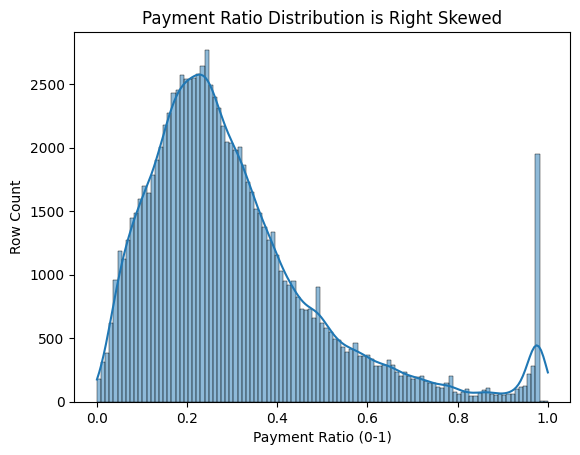

In [148]:
sns.histplot(x=df_sample['payment_ratio'], kde=True)
plt.title("Payment Ratio Distribution is Right Skewed")
plt.xlabel("Payment Ratio (0-1)")
plt.ylabel("Row Count")
plt.show()


In [164]:
df_sample[df_sample['payment_ratio'].between(0.97,1)]

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,...,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt,payment_ratio
5786706,1598031346,Martins Foods Of South Burlington Llc,O,32 Route 82,Hudson,NY,36,12534.0,4.0,Micropolitan area core: primary flow within an...,...,Y,O,169,189.0,189,154.242751,151.158730,151.158730,151.158730,0.980005
6301713,1649287699,Walgreen Eastern Co Inc,O,8277 Broadway,Elmhurst,NY,36,11373,1.0,Metropolitan area core: primary flow within an...,...,N,O,85,85.0,85,34.754353,34.061412,34.061412,31.920000,0.980062
5091205,1518984632,Wal-Mart Stores East Lp,O,265 N Route 73,West Berlin,NJ,34,8091,1.0,Metropolitan area core: primary flow within an...,...,N,O,464,465.0,465,20.732215,20.320710,20.320710,31.920000,0.980151
5064032,1518902410,Garfield Beach Cvs Llc,O,101 Redlands Mall,Redlands,CA,06,92373,1.0,Metropolitan area core: primary flow within an...,...,Y,O,272,272.0,272,83.490000,81.347316,81.347316,81.347316,0.974336
2973231,1306245360,Beck,I,613 23rd St Ste 230,Ashland,KY,21,41101,1.0,Metropolitan area core: primary flow within an...,...,N,O,27,29.0,29,29.000000,28.420000,28.420000,31.920000,0.980000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6077004,1619995032,"Wal-Mart Stores East , Lp",O,18922 Rehoboth Mall Blvd,Rehoboth Beach,DE,10,19971,4.0,Micropolitan area core: primary flow within an...,...,Y,O,138,145.0,145,151.453103,148.422759,148.422759,148.422759,0.979992
2907360,1295769016,Kroger Limited Partnership I,O,50 Stonegate Ctr,Somerset,KY,21,42501,4.0,Micropolitan area core: primary flow within an...,...,Y,O,52,54.0,54,158.445741,155.278889,155.278889,155.278889,0.980013
518302,1053384784,Lee,I,17 Exchange St W Ste 500,Saint Paul,MN,27,55102,1.0,Metropolitan area core: primary flow within an...,...,Y,O,58,59.0,59,68.864407,67.487119,67.487119,67.487119,0.980000
2922627,1295838951,Maryland Cvs Pharmacy Llc,O,133 Baltimore St,Cumberland,MD,24,21502,1.0,Metropolitan area core: primary flow within an...,...,N,O,150,151.0,151,31.114768,30.492715,30.492715,31.920000,0.980008


So we notice a big chunk of submitted charges get paid near 100% but not exactly 100%

# Q1: Variation by State

In [165]:
df_sample.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_Ent_Cd',
       'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn',
       'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA',
       'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type',
       'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc',
       'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs',
       'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt',
       'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt', 'payment_ratio'],
      dtype='object')

In [173]:
valid_states = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL',
    'GA', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME',
    'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH',
    'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI',
    'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'
]
df_q1_states = df[df['Rndrng_Prvdr_State_Abrvtn'].isin(valid_states)]

In [174]:
state_stats = df_q1_states.groupby(['Rndrng_Prvdr_State_Abrvtn']).payment_ratio.agg(['mean', 'std', 'count'])
print(state_stats.sort_values('mean').head(10))
print(state_stats.sort_values('mean').tail(10))

                               mean       std   count
Rndrng_Prvdr_State_Abrvtn                            
WI                         0.210526  0.194671  171140
AK                         0.218277  0.169276   22777
MN                         0.247172  0.185692  202884
MA                         0.263964  0.166300  285293
NH                         0.270500  0.190230   53454
ND                         0.276161  0.177957   27624
GA                         0.276700  0.196359  283554
OR                         0.277297  0.172344  106985
NV                         0.280172  0.192897   75379
IL                         0.282568  0.193361  398174
                               mean       std   count
Rndrng_Prvdr_State_Abrvtn                            
PA                         0.321919  0.195470  442350
KY                         0.324003  0.191663  133944
MD                         0.325124  0.191591  227740
AR                         0.328945  0.196102  103071
VT                         0

Analysis: Trends among states differ for many reasons, one of which might be the Geographic Practice Cost Index (GPCI), which adjusts Medicare's payment formula based on local practice costs. But there is one level deeper to explore as well. GPCI is designed to raise Medicare's payment in high-cost-of-living areas like MA, which, notice, is actually near the low end, not high. If GPCI alone explained this, we expect high-COL states to show higher payment_ratio, since Medicare pays them more to account for local costs. But we seeing Massachusetts at 0.264 (low) and Alabama/South Dakota which are generally LCOL states, sitting at the top (0.35, 0.37). Suggests actually the opposite pattern!

Perhaps payment_ratio isn't just "how much does Medicare pay" but is rather payment ÷ what the provider CHOSE to submit as a charge. GPCI affects the numerator (Medicare's payment), but providers set the denominator (their submitted charge) somewhat independently, often based on regional market norms, what private insurers pay in that area, or local billing customs. Could it be that providers in HCOL states tend to submit higher charges relative to what Medicare's formula actually pays which would be dragging the ratio down, while providers in LCOL states submit charges closer to what Medicare actually reimburses, keeping the ratio higher?

In [176]:
df_q1_states

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,...,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt,payment_ratio
0,1003000126,Enkeshafi,I,6410 Rockledge Dr Ste 304,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389,0.213901
1,1003000126,Enkeshafi,I,6410 Rockledge Dr Ste 304,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133,0.271670
2,1003000126,Enkeshafi,I,6410 Rockledge Dr Ste 304,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365,0.171302
3,1003000126,Enkeshafi,I,6410 Rockledge Dr Ste 304,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250,0.273086
4,1003000126,Enkeshafi,I,6410 Rockledge Dr Ste 304,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857,0.107485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9781668,1992999825,Deschenes,I,1100 9th Ave,Seattle,WA,53,98101,1.0,Metropolitan area core: primary flow within an...,...,N,O,80,92.0,92,330.000000,140.840326,104.658370,93.407065,0.317147
9781669,1992999874,Joffe,I,5620 Brook Rd,Richmond,VA,51,23227,1.0,Metropolitan area core: primary flow within an...,...,N,F,36,36.0,36,780.583333,165.405000,131.781389,133.834444,0.168824
9781670,1992999874,Joffe,I,5620 Brook Rd,Richmond,VA,51,23227,1.0,Metropolitan area core: primary flow within an...,...,N,F,188,329.0,329,278.127660,74.811337,59.662888,61.002462,0.214516
9781671,1992999874,Joffe,I,5620 Brook Rd,Richmond,VA,51,23227,1.0,Metropolitan area core: primary flow within an...,...,N,F,99,153.0,153,398.522876,113.171438,89.568366,90.994967,0.224751


In [ ]:
payments_by_state = (df_q1_states.groupby('Rndrng_Prvdr_State_Abrvtn')[['Avg_Mdcr_Pymt_Amt', 'Avg_Sbmtd_Chrg']].mean())

print(payments_by_state)

['Avg_Mdcr_Pymt_Amt', 'Avg_Sbmtd_Chrg']


In [183]:
payments_sorted = (
    payments_by_state['Avg_Mdcr_Pymt_Amt']
    .sort_values(ascending=False)
    .reset_index()
)

charges_sorted = (
    payments_by_state['Avg_Sbmtd_Chrg']
    .sort_values(ascending=False)
    .reset_index()
)

side_by_side = pd.concat([payments_sorted, charges_sorted], axis=1)
side_by_side

,Rndrng_Prvdr_State_Abrvtn,Avg_Mdcr_Pymt_Amt,Rndrng_Prvdr_State_Abrvtn,Avg_Sbmtd_Chrg
0,AK,106.784011,AK,843.184597
1,CA,99.761534,WI,610.569035
2,AZ,99.663389,NV,538.070331
3,MD,97.440800,NH,531.764172
4,FL,96.936552,NJ,519.491807
5,DC,96.316638,CA,510.607802
6,NV,94.895309,AZ,504.971496
7,DE,88.645096,NY,498.736813
8,NJ,88.538620,FL,488.240400
9,TX,87.151125,TX,487.170986


An important note, though. Our hypothesis for Q1 concerns the distribution of the ratio itself in that I'm asking "does the typical claim's  ratio differ by state." That's a  quantity answered through understanding each row already has its own payment_ratio, and ANOVA on group means of that variable is testing exactly what the H0/H1 say. mean(payment)/mean(charge) instead answers a different question closer to "if you pooled all of a state's dollars together, what fraction comes back". So ignore that second question right now. Mismatches like this between an aggregate ratio and a average of ratios at row level reminds me of a Simpson's-paradox-adjacent behavior, where aggregation direction changes the story

In [207]:
model = ols('payment_ratio ~ C(Rndrng_Prvdr_State_Abrvtn)', data=df_q1_states).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                     sum_sq         df            F  PR(>F)
C(Rndrng_Prvdr_State_Abrvtn)    5035.271402       50.0  2589.610191     0.0
Residual                      379428.528905  9756892.0          NaN     NaN


Analysis: Our ANOVA results that there is significant (p-value < 0.05) difference in mean payment ratios between states. The F-statistic is large and is a ratio of variances within and between groups. However, with millions of rows and 51 states, small differences may get obfuscated. η² is a metric that will tell us how much practical weight that difference carries. With over a million rows, one could get a "highly significant" result even if state only explains 1% of the variation which would mean statistically real but irrelevant.

In [208]:
#take sum_sq or sum of squared differences between states and find what fraction of total variation it is
eta_q1 = 5035.271402 / (5035.271402 + 379428.528905)
eta_q1


0.01309686737211478

Using a one-way ANOVA test, I find that there is a significant difference between mean payment ratios of the US states. However, the variation between states is only a small fraction of the total variation among the data (1.3%), so other sources of variation certainly exist. Proof of this can be seen where the standard deviations within states hover around 0.19-0.24 std which is large relative to the ~0.15 spread between state means. The result here motivates Q2, where I aim to find a predictive model that explain the 98.7% of variation remaining by looking at factors other than just state.

After these results, now we can use Tukey HSD test as a post-hoc test to see significance of each pair of states. Tukey HSD is the classic tool for controlling that risk specifically for all pairwise comparisons after an ANOVA where Tukey controls "chance of ANY false positive across all pairs".

In [212]:
tukey_results = pairwise_tukeyhsd(endog=df_q1_states['payment_ratio'],
                                   groups=df_q1_states['Rndrng_Prvdr_State_Abrvtn'],
                                   alpha=0.05)
print(tukey_results)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    AK     AL   0.1316    0.0   0.126  0.1372   True
    AK     AR   0.1107    0.0  0.1049  0.1164   True
    AK     AZ   0.0858    0.0  0.0803  0.0913   True
    AK     CA    0.082    0.0  0.0767  0.0873   True
    AK     CO    0.077    0.0  0.0714  0.0826   True
    AK     CT   0.0858    0.0  0.0801  0.0915   True
    AK     DC   0.0878    0.0  0.0807   0.095   True
    AK     DE   0.1036    0.0  0.0971  0.1102   True
    AK     FL   0.0965    0.0  0.0912  0.1018   True
    AK     GA   0.0584    0.0   0.053  0.0639   True
    AK     HI   0.1127    0.0  0.1056  0.1199   True
    AK     IA   0.0846    0.0  0.0788  0.0904   True
    AK     ID   0.0972    0.0  0.0908  0.1036   True
    AK     IL   0.0643    0.0  0.0589  0.0697   True
    AK     IN   0.1025    0.0  0.0969   0.108   True
    AK     KS   0.0858    0.0  0.0801  0.0916 

In [230]:
print((tukey_results.reject == True).sum())
print((tukey_results.reject == False).sum())

1149
126


In [232]:
tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:], 
                         columns=tukey_results._results_table.data[0])

tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,AK,AL,0.1316,0.0000,0.1260,0.1372,True
1,AK,AR,0.1107,0.0000,0.1049,0.1164,True
2,AK,AZ,0.0858,0.0000,0.0803,0.0913,True
3,AK,CA,0.0820,0.0000,0.0767,0.0873,True
4,AK,CO,0.0770,0.0000,0.0714,0.0826,True
...,...,...,...,...,...,...,...
1270,WA,WV,0.0070,0.0000,0.0030,0.0109,True
1271,WA,WY,0.0101,0.0000,0.0041,0.0161,True
1272,WI,WV,0.0907,0.0000,0.0867,0.0948,True
1273,WI,WY,0.0939,0.0000,0.0878,0.1000,True


Pick a threshold, filter tukey_df for reject == True and abs(meandiff) > your_threshold, sort by meandiff descending, and tell me how many pairs survive and which states show up most often at the extremes.

In [236]:
tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,AK,AL,0.1316,0.0000,0.1260,0.1372,True
1,AK,AR,0.1107,0.0000,0.1049,0.1164,True
2,AK,AZ,0.0858,0.0000,0.0803,0.0913,True
3,AK,CA,0.0820,0.0000,0.0767,0.0873,True
4,AK,CO,0.0770,0.0000,0.0714,0.0826,True
...,...,...,...,...,...,...,...
1270,WA,WV,0.0070,0.0000,0.0030,0.0109,True
1271,WA,WY,0.0101,0.0000,0.0041,0.0161,True
1272,WI,WV,0.0907,0.0000,0.0867,0.0948,True
1273,WI,WY,0.0939,0.0000,0.0878,0.1000,True


In [240]:
tukey_threshold = 0.10
filtered_tukey = tukey_df[(tukey_df['reject'] == True) & (abs(tukey_df['meandiff']) > tukey_threshold )].sort_values(by='meandiff',ascending=False)

In [246]:
print(filtered_tukey.groupby('group1').count())
print(filtered_tukey.groupby('group2').count())

        group2  meandiff  p-adj  lower  upper  reject
group1                                               
AK          14        14     14     14     14      14
AL           2         2      2      2      2       2
AR           1         1      1      1      1       1
DE           1         1      1      1      1       1
FL           1         1      1      1      1       1
HI           1         1      1      1      1       1
ID           1         1      1      1      1       1
IN           1         1      1      1      1       1
KY           1         1      1      1      1       1
MA           1         1      1      1      1       1
MD           1         1      1      1      1       1
MI           1         1      1      1      1       1
MN           1         1      1      1      1       1
MT           1         1      1      1      1       1
NJ           1         1      1      1      1       1
OK           1         1      1      1      1       1
PA           1         1    

Analysis: Tukey HSD showed that the majority of pairwise comparisons resulted in a rejection, meaning the states were significantly different. However, when filtering the mean differences by some large threshold like 0.10, 34 rows were returned. However, 32/34 of these rows were from AK or WI states. the practically meaningful differences are concentrated in a small handful of extreme states (AK high, WI/SD/AL low) rather than being broadly distributed and most of the remaining ~45 states cluster fairly close to each other. Connecting back to the ANOVA test, let us see what removing WI and AK does for our sum of squared differences:

In [249]:
df_q1_states_exclude_outlier_states = df_q1_states[
    ~df_q1_states['Rndrng_Prvdr_State_Abrvtn'].isin(['AK', 'WI'])
]

model = ols('payment_ratio ~ C(Rndrng_Prvdr_State_Abrvtn)', data=df_q1_states_exclude_outlier_states).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                     sum_sq         df            F  PR(>F)
C(Rndrng_Prvdr_State_Abrvtn)    3431.638217       48.0  1836.418713     0.0
Residual                      372290.247905  9562977.0          NaN     NaN


In [250]:
3431.638217 / (3431.638217 + 372290.247905)

0.009133453077273541

Excluding AK and WI, η² drops from ~1.3% to ~0.9% which is a real but modest reduction, confirming that these two states account for a disproportionate share of the already small state-level effect.

In [262]:
state_stats.reset_index(inplace=True)

In [266]:
fig = px.choropleth(
    state_stats,
    locations='Rndrng_Prvdr_State_Abrvtn',
    locationmode='USA-states',
    color='mean',
    hover_name='Rndrng_Prvdr_State_Abrvtn',
    color_continuous_scale='Viridis',
    scope='usa',
    title='U.S. States by Medicare Payment & Submission Ratio'
)
fig